# Identitas Diri
Nama : Muhammad Fattahul Alim

NIM : 244107020018

Kelas : TI - 3G

Absen : 15


In [2]:
# import library dan setting
import os
import time
import warnings
from collections import deque
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import DBSCAN  # hanya untuk validasi kelas manual
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score,
    pairwise_distances,
    adjusted_rand_score
)

from google.colab import drive
drive.mount('/content/drive')

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['figure.dpi'] = 120

METRIC = 'manhattan'
RANDOM_STATE = 42
N_SAMPLE = 10000   # jumlah data yang sama untuk semua notebook (K-Means dan DBSCAN)
np.random.seed(RANDOM_STATE)

OUTPUT_DIR = "/content/drive/MyDrive/ml-sem5/kuis1/outputDBSCAN_5050"
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("[INFO] Library berhasil diinstall.")
print(f"[INFO] Folder output: '{OUTPUT_DIR}' | Random state: {RANDOM_STATE} | N_SAMPLE: {N_SAMPLE}")

Mounted at /content/drive
[INFO] Library berhasil diinstall.
[INFO] Folder output: '/content/drive/MyDrive/ml-sem5/kuis1/outputDBSCAN_5050' | Random state: 42 | N_SAMPLE: 10000


In [3]:
# load dataset
DATASET_PATH = '/content/drive/MyDrive/ml-sem5/kuis1/dataset/diabetes_binary_5050split_health_indicators_BRFSS2015.csv'
df_raw = pd.read_csv(DATASET_PATH)
print(f"Data awal: {df_raw.shape[0]} baris x {df_raw.shape[1]} kolom")
df_raw.head()


Data awal: 70692 baris x 22 kolom


,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,0.0,1.0,26.0,0.0,0.0,0.0,1.0,0.0,...,1.0,0.0,3.0,5.0,30.0,0.0,1.0,4.0,6.0,8.0
1,0.0,1.0,1.0,1.0,26.0,1.0,1.0,0.0,0.0,1.0,...,1.0,0.0,3.0,0.0,0.0,0.0,1.0,12.0,6.0,8.0
2,0.0,0.0,0.0,1.0,26.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,1.0,0.0,10.0,0.0,1.0,13.0,6.0,8.0
3,0.0,1.0,1.0,1.0,28.0,1.0,0.0,0.0,1.0,1.0,...,1.0,0.0,3.0,0.0,3.0,0.0,1.0,11.0,6.0,8.0
4,0.0,0.0,0.0,1.0,29.0,1.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,8.0,5.0,8.0


In [4]:
# cek data awal
print("Tipe data tiap kolom:")
print(df_raw.dtypes.value_counts())

print("\nTotal missing value per kolom (hanya yang > 0):")
missing = df_raw.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else "Tidak ada missing value")

print(f"\nJumlah baris duplikat: {df_raw.duplicated().sum()}")

print("\nSebaran kelas Diabetes_binary (0 = tidak diabetes, 1 = diabetes):")
print(df_raw['Diabetes_binary'].value_counts().sort_index())

Tipe data tiap kolom:
float64    22
Name: count, dtype: int64

Total missing value per kolom (hanya yang > 0):
Tidak ada missing value

Jumlah baris duplikat: 1635

Sebaran kelas Diabetes_binary (0 = tidak diabetes, 1 = diabetes):
Diabetes_binary
0.0    35346
1.0    35346
Name: count, dtype: int64


In [5]:
# preprocessing + sampling
LABEL_COL = 'Diabetes_binary'
DROP_COLS = ['Income', 'Education', 'AnyHealthcare', 'NoDocbcCost', 'CholCheck', 'HvyAlcoholConsump']

df = df_raw.drop(columns=DROP_COLS)
print(f"Setelah buang kolom        : {df.shape[1]} kolom (termasuk label)")

n_sebelum_dup = len(df)
df = df.drop_duplicates().reset_index(drop=True)
print(f"Setelah hapus duplikat     : {len(df)} baris (terbuang {n_sebelum_dup - len(df)})")
print(f"Sebaran kelas              : {df[LABEL_COL].value_counts().sort_index().to_dict()}")

# Sampel seimbang: jumlah data per kelas sama, seed sama -> data identik di semua notebook
n_per_kelas = N_SAMPLE // 2
assert df[LABEL_COL].value_counts().min() >= n_per_kelas, "Salah satu kelas kurang dari jumlah sampel per kelas"
df_sample_all = (df.groupby(LABEL_COL).sample(n=n_per_kelas, random_state=RANDOM_STATE)
                   .sample(frac=1, random_state=RANDOM_STATE)
                   .reset_index(drop=True))

y_sample = df_sample_all[LABEL_COL].copy()   # label hanya untuk pembanding, tidak dipakai klastering
df_features = df_sample_all.drop(columns=[LABEL_COL]).astype(float)
print(f"Data klastering            : {df_features.shape[0]} baris x {df_features.shape[1]} fitur")
print(f"Sebaran label sampel       : {y_sample.value_counts().sort_index().to_dict()}")
print(f"Daftar fitur               : {list(df_features.columns)}")

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_features.values)
print(f"Cek mean 0 dan std 1       : {X_scaled.mean():.4f} / {X_scaled.std():.4f}")
X_sample = X_scaled
df_features.head()

Setelah buang kolom        : 16 kolom (termasuk label)
Setelah hapus duplikat     : 63197 baris (terbuang 7495)
Sebaran kelas              : {0.0: 29885, 1.0: 33312}
Data klastering            : 10000 baris x 15 fitur
Sebaran label sampel       : {0.0: 5000, 1.0: 5000}
Daftar fitur               : ['HighBP', 'HighChol', 'BMI', 'Smoker', 'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies', 'GenHlth', 'MentHlth', 'PhysHlth', 'DiffWalk', 'Sex', 'Age']
Cek mean 0 dan std 1       : -0.0000 / 1.0000


,HighBP,HighChol,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age
0,1.0,1.0,26.0,1.0,0.0,1.0,0.0,1.0,1.0,5.0,30.0,30.0,1.0,1.0,11.0
1,1.0,0.0,30.0,1.0,0.0,0.0,1.0,1.0,1.0,2.0,0.0,0.0,0.0,1.0,11.0
2,1.0,0.0,35.0,1.0,0.0,0.0,0.0,1.0,1.0,4.0,5.0,20.0,1.0,0.0,11.0
3,1.0,1.0,26.0,1.0,0.0,0.0,0.0,0.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0
4,0.0,0.0,24.0,1.0,0.0,0.0,0.0,0.0,0.0,3.0,0.0,0.0,0.0,1.0,7.0


[PARAM] MinPts = 30
[K-DIST] Saran eps dari siku kurva: 6.4195
[K-DIST] Persentil ke-50: 3.5675
[K-DIST] Persentil ke-75: 5.0450
[K-DIST] Persentil ke-90: 6.3686
[K-DIST] Persentil ke-95: 7.1753
[K-DIST] Persentil ke-99: 8.6766
[SIMPAN] Grafik k-distance disimpan ke: '/content/drive/MyDrive/ml-sem5/kuis1/outputDBSCAN_5050/kdistance_manhattan.png'


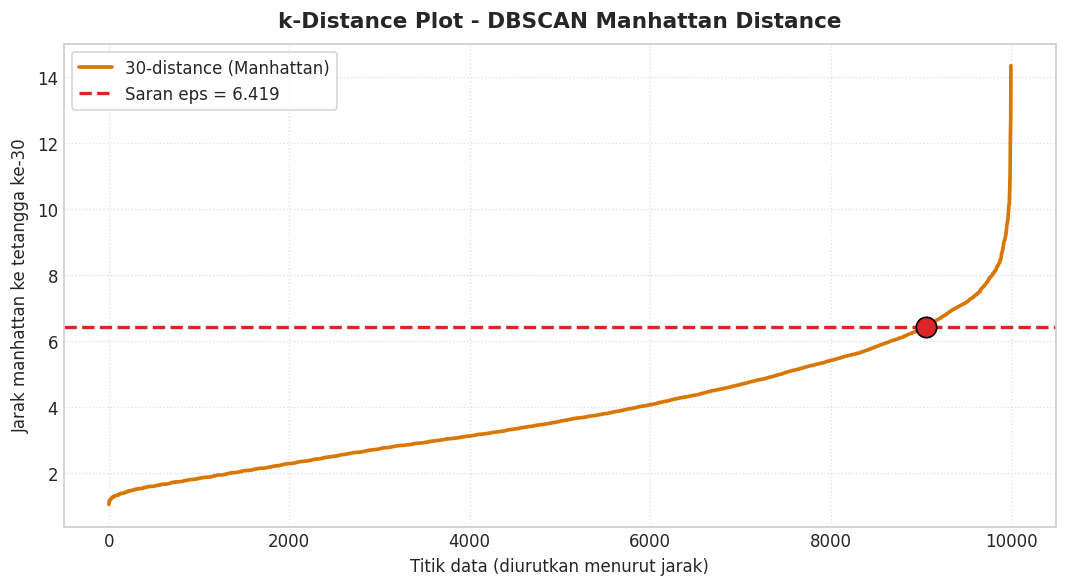

In [6]:
#k-distance plot untuk menentukan eps (pengganti Elbow Method)
MIN_PTS = 2 * X_sample.shape[1]   # heuristik: 2 x jumlah fitur
print(f"[PARAM] MinPts = {MIN_PTS}")

nbrs = NearestNeighbors(n_neighbors=MIN_PTS, metric=METRIC, algorithm='brute', n_jobs=-1).fit(X_sample)
distances, _ = nbrs.kneighbors(X_sample)
k_dist = np.sort(distances[:, -1])

def find_knee_point(y_vals):
    x = np.arange(len(y_vals), dtype=float)
    xn = (x - x.min()) / (x.max() - x.min())
    yn = (y_vals - y_vals.min()) / (y_vals.max() - y_vals.min())
    p1 = np.array([xn[0], yn[0]])
    line_unit = np.array([xn[-1], yn[-1]]) - p1
    line_unit = line_unit / np.linalg.norm(line_unit)
    pts = np.column_stack([xn, yn]) - p1
    proj = np.outer(pts @ line_unit, line_unit)
    return int(np.argmax(np.linalg.norm(pts - proj, axis=1)))

knee_idx = find_knee_point(k_dist)
eps_suggest = float(k_dist[knee_idx])
print(f"[K-DIST] Saran eps dari siku kurva: {eps_suggest:.4f}")
for q in [50, 75, 90, 95, 99]:
    print(f"[K-DIST] Persentil ke-{q}: {np.percentile(k_dist, q):.4f}")

plt.figure(figsize=(9, 5))
plt.plot(k_dist, linewidth=2.2, color='#D97706', label=f'{MIN_PTS}-distance (Manhattan)')
plt.axhline(eps_suggest, color='#DC2626', linestyle='--', linewidth=2, label=f'Saran eps = {eps_suggest:.3f}')
plt.scatter([knee_idx], [eps_suggest], color='#DC2626', s=150, zorder=5, edgecolor='black')
plt.title('k-Distance Plot - DBSCAN Manhattan Distance', fontsize=13, fontweight='bold', pad=10)
plt.xlabel('Titik data (diurutkan menurut jarak)')
plt.ylabel(f'Jarak manhattan ke tetangga ke-{MIN_PTS}')
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(frameon=True, facecolor='white')
plt.tight_layout()

kdist_path = os.path.join(OUTPUT_DIR, "kdistance_manhattan.png")
plt.savefig(kdist_path, dpi=300)
print(f"[SIMPAN] Grafik k-distance disimpan ke: '{kdist_path}'")
plt.show()


In [7]:
# Class DBSCAN Manhattan (implementasi manual)
class DBSCANManhattan:
    def __init__(self, eps=0.5, min_pts=5, chunk_size=1000):
        self.eps = eps
        self.min_pts = min_pts
        self.chunk_size = chunk_size
        self.labels_ = None
        self.core_sample_mask_ = None
        self.n_clusters_ = 0
        self.n_noise_ = 0
        self.execution_time_ = 0.0

    def _neighborhoods(self, X):
        # N_eps(p) = { q | d(p, q) <= eps }, termasuk p sendiri; dihitung per potongan agar hemat RAM
        out = []
        for s in range(0, len(X), self.chunk_size):
            d = pairwise_distances(X[s:s + self.chunk_size], X, metric='manhattan', n_jobs=-1)
            out.extend(np.where(row <= self.eps)[0].astype(np.int32) for row in d)
        return out

    def fit(self, X):
        start = time.perf_counter()
        n = X.shape[0]
        neighborhoods = self._neighborhoods(X)
        is_core = np.array([len(nb) >= self.min_pts for nb in neighborhoods])

        labels = np.full(n, -1, dtype=int)   # -1 = noise
        visited = np.zeros(n, dtype=bool)
        cluster_id = 0

        for p in range(n):
            if visited[p] or not is_core[p]:
                continue
            visited[p] = True
            labels[p] = cluster_id
            seeds = deque([p])
            while seeds:
                q = seeds.popleft()
                nb = neighborhoods[q]
                labels[nb[labels[nb] == -1]] = cluster_id          # border/core masuk klaster ini
                new_core = nb[(~visited[nb]) & is_core[nb]]        # core baru ikut diekspansi
                visited[new_core] = True
                seeds.extend(new_core.tolist())
            cluster_id += 1

        self.labels_ = labels
        self.core_sample_mask_ = is_core
        self.n_clusters_ = cluster_id
        self.n_noise_ = int(np.sum(labels == -1))
        self.execution_time_ = float(time.perf_counter() - start)
        return self

print("[INFO] Kelas DBSCANManhattan berhasil diinisialisasi.")

[INFO] Kelas DBSCANManhattan berhasil diinisialisasi.


In [8]:
# uji validasi terhadap DBSCAN sklearn (eps dan MinPts sama)
EPS_TEST = float(np.percentile(k_dist, 70))

mine = DBSCANManhattan(eps=EPS_TEST, min_pts=MIN_PTS).fit(X_sample)
ref = DBSCAN(eps=EPS_TEST, min_samples=MIN_PTS, metric='manhattan', algorithm='brute').fit(X_sample)

ref_core = np.zeros(len(X_sample), dtype=bool)
ref_core[ref.core_sample_indices_] = True

print(f"[VALIDASI] eps = {EPS_TEST:.4f} | MinPts = {MIN_PTS}")
print(f"[VALIDASI] Manual : {mine.n_clusters_} klaster, {mine.n_noise_} noise, {mine.execution_time_:.2f} detik")
print(f"[VALIDASI] sklearn: {len(set(ref.labels_)) - (1 if -1 in ref.labels_ else 0)} klaster, {int(np.sum(ref.labels_ == -1))} noise")
print(f"[VALIDASI] Core point identik : {np.array_equal(mine.core_sample_mask_, ref_core)}")
print(f"[VALIDASI] Noise identik      : {np.array_equal(mine.labels_ == -1, ref.labels_ == -1)}")
print(f"[VALIDASI] Adjusted Rand Index: {adjusted_rand_score(ref.labels_, mine.labels_):.4f}")

[VALIDASI] eps = 4.6878 | MinPts = 30
[VALIDASI] Manual : 1 klaster, 1145 noise, 2.56 detik
[VALIDASI] sklearn: 1 klaster, 1145 noise
[VALIDASI] Core point identik : True
[VALIDASI] Noise identik      : True
[VALIDASI] Adjusted Rand Index: 1.0000


In [9]:
# uji beberapa nilai eps
eps_candidates = sorted(set(round(float(np.percentile(k_dist, q)), 4) for q in [50, 60, 70, 80, 90, 95]) | {round(eps_suggest, 4)})
rows = []

for eps in eps_candidates:
    m = DBSCANManhattan(eps=eps, min_pts=MIN_PTS).fit(X_sample)
    lab = m.labels_
    mk = lab != -1
    largest = np.bincount(lab[mk]).max() / len(lab) * 100 if m.n_clusters_ > 0 else 0.0

    if m.n_clusters_ >= 2:
        sil = silhouette_score(X_sample[mk], lab[mk], metric='manhattan')
    else:
        sil = np.nan

    rows.append({
        'eps': eps,
        'Jumlah Klaster': m.n_clusters_,
        'Noise (n)': m.n_noise_,
        'Noise (%)': round(m.n_noise_ / len(lab) * 100, 2),
        'Klaster Terbesar (%)': round(largest, 2),
        'Core Point (n)': int(m.core_sample_mask_.sum()),
        'Silhouette (non-noise)': round(sil, 4) if not np.isnan(sil) else np.nan,
        'Waktu (s)': round(m.execution_time_, 2)
    })
    print(f"[SWEEP] eps={eps} -> {m.n_clusters_} klaster, noise {m.n_noise_ / len(lab) * 100:.2f}%")

sweep_df = pd.DataFrame(rows)
print("\n" + "=" * 100)
print("TABEL UJI EPS - DBSCAN MANHATTAN")
print("=" * 100)
print(sweep_df.to_string(index=False))

sweep_path = os.path.join(OUTPUT_DIR, "eps_sweep_manhattan.csv")
sweep_df.to_csv(sweep_path, index=False)
print(f"[SIMPAN] Tabel uji eps disimpan ke: '{sweep_path}'")

[SWEEP] eps=3.5675 -> 1 klaster, noise 28.30%
[SWEEP] eps=4.0738 -> 1 klaster, noise 19.68%
[SWEEP] eps=4.6878 -> 1 klaster, noise 11.45%
[SWEEP] eps=5.4114 -> 1 klaster, noise 4.84%
[SWEEP] eps=6.3686 -> 1 klaster, noise 1.25%
[SWEEP] eps=6.4195 -> 1 klaster, noise 1.16%
[SWEEP] eps=7.1753 -> 1 klaster, noise 0.34%

TABEL UJI EPS - DBSCAN MANHATTAN
   eps  Jumlah Klaster  Noise (n)  Noise (%)  Klaster Terbesar (%)  Core Point (n)  Silhouette (non-noise)  Waktu (s)
3.5675               1       2830      28.30                 71.70            5000                     NaN       3.41
4.0738               1       1968      19.68                 80.32            6000                     NaN       3.94
4.6878               1       1145      11.45                 88.55            7000                     NaN       2.46
5.4114               1        484       4.84                 95.16            8000                     NaN       2.52
6.3686               1        125       1.25              

In [10]:
# model final, evaluasi, profil klaster, simpan hasil
EPS_MANUAL = None

ok = sweep_df[(sweep_df['Jumlah Klaster'] >= 2) & (sweep_df['Noise (%)'] <= 30)]
if EPS_MANUAL is not None:
    EPS_FINAL = float(EPS_MANUAL)
elif len(ok) > 0:
    EPS_FINAL = float(ok.sort_values('Silhouette (non-noise)', ascending=False).iloc[0]['eps'])   # klaster >= 2, noise <= 30%, silhouette tertinggi
else:
    EPS_FINAL = float(eps_suggest)
print(f"[FINAL] eps = {EPS_FINAL} | MinPts = {MIN_PTS}")

model_dbscan = DBSCANManhattan(eps=EPS_FINAL, min_pts=MIN_PTS).fit(X_sample)
labels = model_dbscan.labels_
mask = labels != -1
n_total = len(labels)

# Metrik dihitung pada titik non-noise (noise bukan klaster)
if model_dbscan.n_clusters_ >= 2:
    sil_score = float(silhouette_score(X_sample[mask], labels[mask], metric='manhattan'))
    db_score = float(davies_bouldin_score(X_sample[mask], labels[mask]))
    ch_score = float(calinski_harabasz_score(X_sample[mask], labels[mask]))
else:
    sil_score = db_score = ch_score = np.nan

sizes = np.bincount(labels[mask]) if model_dbscan.n_clusters_ > 0 else np.array([0])

eval_df = pd.DataFrame([{
    'Distance Metric': 'Manhattan Distance (L1)',
    'eps': EPS_FINAL,
    'MinPts': MIN_PTS,
    'Jumlah Data Dipakai': n_total,
    'Jumlah Fitur': X_sample.shape[1],
    'Jumlah Klaster': model_dbscan.n_clusters_,
    'Klaster >=1% data': int(np.sum(sizes >= 0.01 * n_total)),
    'Klaster Terbesar (%)': round(sizes.max() / n_total * 100, 2),
    'Noise (n)': model_dbscan.n_noise_,
    'Noise (%)': round(model_dbscan.n_noise_ / n_total * 100, 2),
    'Core Point (n)': int(model_dbscan.core_sample_mask_.sum()),
    'Silhouette Score (non-noise) (↑)': round(sil_score, 4),
    'Davies–Bouldin Index (non-noise) (↓)': round(db_score, 4),
    'Calinski–Harabasz Index (non-noise) (↑)': round(ch_score, 2),
    'Execution Time (s) (↓)': round(model_dbscan.execution_time_, 5)
}])

print("\n" + "=" * 80)
print("TABEL EVALUASI DBSCAN MANHATTAN")
print("=" * 80)
print(eval_df.T.to_string(header=False))
print("=" * 80)

df_result = df_features.copy()
df_result['Cluster_DBSCAN'] = labels
df_result['Diabetes_binary'] = y_sample.values

profil = df_result.groupby('Cluster_DBSCAN').mean().round(3)
profil.insert(0, 'Jumlah Data', df_result.groupby('Cluster_DBSCAN').size())
profil['% Diabetes'] = df_result.groupby('Cluster_DBSCAN')['Diabetes_binary'].apply(lambda s: (s == 1).mean() * 100).round(2)

excel_path = os.path.join(OUTPUT_DIR, "evaluasi_dbscan_manhattan.xlsx")
with pd.ExcelWriter(excel_path, engine='openpyxl') as writer:
    eval_df.to_excel(writer, sheet_name='Ringkasan_Evaluasi', index=False)
    profil.to_excel(writer, sheet_name='Profil_Klaster')
print(f"[SIMPAN] Evaluasi & profil klaster disimpan ke: '{excel_path}'")

csv_path = os.path.join(OUTPUT_DIR, "data_terklaster_dbscan_manhattan.csv")
df_result.to_csv(csv_path, index=False)
print(f"[SIMPAN] Data terklaster disimpan ke: '{csv_path}'")

[FINAL] eps = 6.4194720135505 | MinPts = 30

TABEL EVALUASI DBSCAN MANHATTAN
Distance Metric                          Manhattan Distance (L1)
eps                                                     6.419472
MinPts                                                        30
Jumlah Data Dipakai                                        10000
Jumlah Fitur                                                  15
Jumlah Klaster                                                 1
Klaster >=1% data                                              1
Klaster Terbesar (%)                                       98.84
Noise (n)                                                    116
Noise (%)                                                   1.16
Core Point (n)                                              9054
Silhouette Score (non-noise) (↑)                             NaN
Davies–Bouldin Index (non-noise) (↓)                         NaN
Calinski–Harabasz Index (non-noise) (↑)                      NaN
Execution Tim

In [11]:
# profil tiap klaster (label -1 = noise)
profil

,Jumlah Data,HighBP,HighChol,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Diabetes_binary,% Diabetes
Cluster_DBSCAN,,,,,,,,,,,,,,,,,,
-1,116,0.603,0.440,39.534,0.526,0.776,0.517,0.371,0.431,0.448,4.034,18.086,19.293,0.629,0.353,8.655,0.672,67.24
0,9884,0.571,0.535,29.995,0.498,0.058,0.151,0.678,0.590,0.773,2.891,4.024,6.242,0.271,0.457,8.587,0.498,49.80


[SIMPAN] Grafik pemetaan klaster disimpan ke: '/content/drive/MyDrive/ml-sem5/kuis1/outputDBSCAN_5050/cluster_dbscan_manhattan.png'


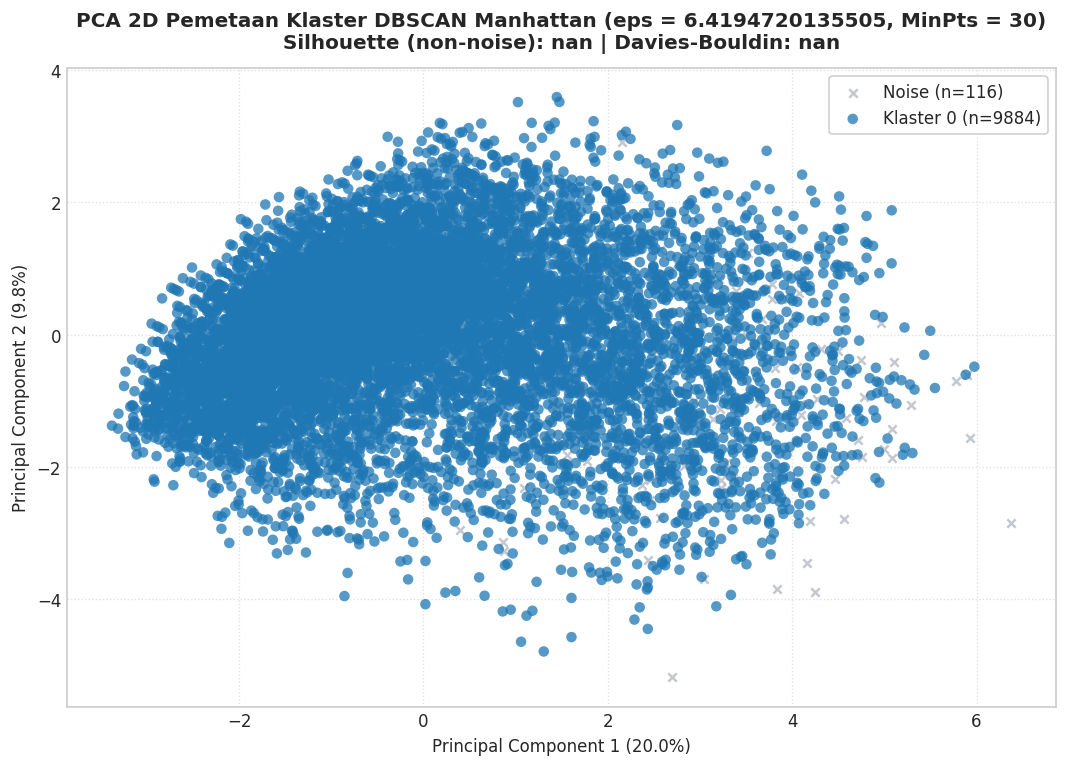

In [12]:
# visualisasi PCA 2D pemetaan klaster
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_sample)

plt.figure(figsize=(9, 6.5))
n_cl = model_dbscan.n_clusters_
palette = sns.color_palette("tab10", max(n_cl, 1))

m_noise = labels == -1
plt.scatter(X_pca[m_noise, 0], X_pca[m_noise, 1], c='#9CA3AF', marker='x', s=25, alpha=0.6,
            label=f'Noise (n={m_noise.sum()})')
for k in range(n_cl):
    mk = labels == k
    plt.scatter(X_pca[mk, 0], X_pca[mk, 1], color=palette[k], s=40, alpha=0.75, edgecolors='none',
                label=f'Klaster {k} (n={mk.sum()})')

plt.title(f'PCA 2D Pemetaan Klaster DBSCAN Manhattan (eps = {EPS_FINAL}, MinPts = {MIN_PTS})\n'
          f'Silhouette (non-noise): {sil_score:.4f} | Davies-Bouldin: {db_score:.4f}',
          fontsize=12, fontweight='bold', pad=12)
plt.xlabel(f'Principal Component 1 ({pca.explained_variance_ratio_[0] * 100:.1f}%)')
plt.ylabel(f'Principal Component 2 ({pca.explained_variance_ratio_[1] * 100:.1f}%)')
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(frameon=True, facecolor='white', framealpha=0.9, loc='best')
plt.tight_layout()

cluster_path = os.path.join(OUTPUT_DIR, "cluster_dbscan_manhattan.png")
plt.savefig(cluster_path, dpi=300)
print(f"[SIMPAN] Grafik pemetaan klaster disimpan ke: '{cluster_path}'")
plt.show()


In [13]:
# fitur paling berpengaruh di PC1 & PC2
loadings = pd.DataFrame(pca.components_.T, index=df_features.columns, columns=['PC1', 'PC2'])
print("Fitur paling berpengaruh di PC1:")
print(loadings['PC1'].abs().sort_values(ascending=False).head(6).round(3))
print("\nFitur paling berpengaruh di PC2:")
print(loadings['PC2'].abs().sort_values(ascending=False).head(6).round(3))

Fitur paling berpengaruh di PC1:
GenHlth                 0.440
DiffWalk                0.406
PhysHlth                0.395
HighBP                  0.301
HeartDiseaseorAttack    0.262
PhysActivity            0.243
Name: PC1, dtype: float64

Fitur paling berpengaruh di PC2:
Age                     0.525
MentHlth                0.459
HighBP                  0.328
HeartDiseaseorAttack    0.298
PhysHlth                0.276
HighChol                0.265
Name: PC2, dtype: float64


In [14]:
# klaster vs label diabetes (pembanding)
label_vs = pd.crosstab(df_result['Cluster_DBSCAN'], df_result['Diabetes_binary'])
label_vs.columns = ['Tidak Diabetes (0)' if c == 0 else 'Diabetes (1)' for c in label_vs.columns]
label_vs['Total'] = label_vs.sum(axis=1)
if 'Diabetes (1)' in label_vs.columns:
    label_vs['Diabetes (%)'] = (label_vs['Diabetes (1)'] / label_vs['Total'] * 100).round(2)
print(f"Proporsi diabetes seluruh sampel = {(y_sample == 1).mean() * 100:.2f}%")
print(label_vs.to_string())

if model_dbscan.n_clusters_ >= 2:
    ari = adjusted_rand_score(y_sample.values[mask], labels[mask])
    print(f"\nARI klaster vs label (non-noise): {ari:.4f}")
diab_noise = int(((labels == -1) & (y_sample.values == 1)).sum())
print(f"Diabetes di noise: {diab_noise} dari {int((y_sample == 1).sum())}")


Proporsi diabetes seluruh sampel = 50.00%
                Tidak Diabetes (0)  Diabetes (1)  Total  Diabetes (%)
Cluster_DBSCAN                                                       
-1                              38            78    116         67.24
 0                            4962          4922   9884         49.80
Diabetes di noise: 78 dari 5000


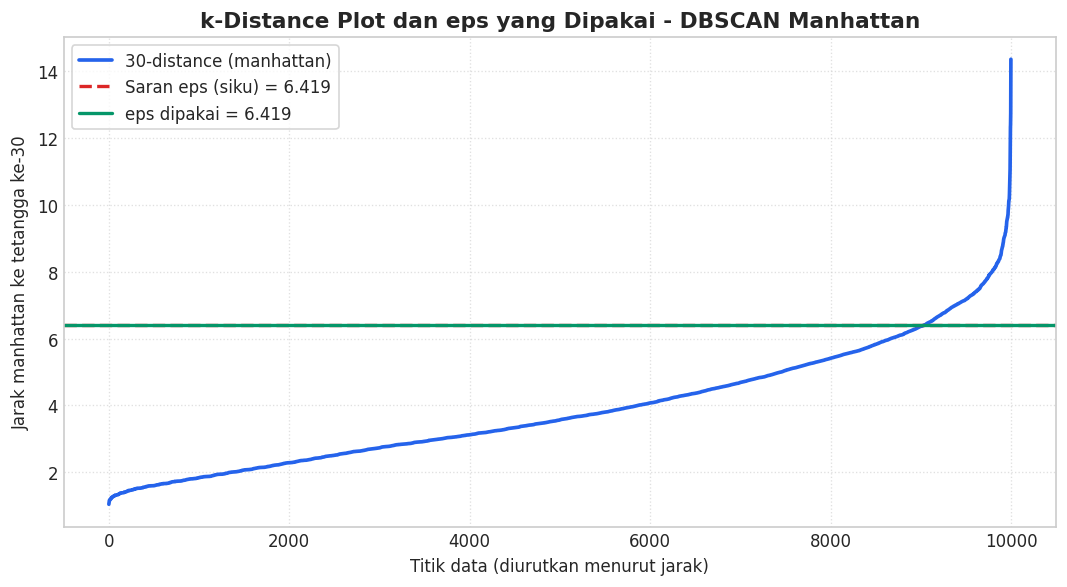

In [15]:
# k-distance plot dengan eps yang dipakai
plt.figure(figsize=(9, 5))
plt.plot(k_dist, linewidth=2.2, color='#2563EB', label=f'{MIN_PTS}-distance ({METRIC})')
plt.axhline(eps_suggest, color='#DC2626', linestyle='--', linewidth=2, label=f'Saran eps (siku) = {eps_suggest:.3f}')
plt.axhline(EPS_FINAL, color='#059669', linestyle='-', linewidth=2, label=f'eps dipakai = {EPS_FINAL:.3f}')
plt.title(f'k-Distance Plot dan eps yang Dipakai - DBSCAN {METRIC.capitalize()}', fontsize=13, fontweight='bold')
plt.xlabel('Titik data (diurutkan menurut jarak)')
plt.ylabel(f'Jarak {METRIC} ke tetangga ke-{MIN_PTS}')
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(frameon=True, facecolor='white')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, f"kdistance_eps_final_{METRIC}.png"), dpi=300)
plt.show()

In [16]:
# bukti pendukung - jarak satu perbedaan pada fitur biner
# Setelah standardisasi, satu perbedaan pada fitur biner bernilai 1/sigma.
# Kalau nilainya > eps, dua titik yang beda di fitur itu tidak mungkin bertetangga.
gap_rows = []
for col, sigma in zip(df_features.columns, scaler.scale_):
    if df_features[col].nunique() == 2:
        gap_rows.append({
            'Fitur': col,
            'Proporsi nilai 1': round(df_features[col].mean(), 3),
            'Sigma': round(sigma, 4),
            'Jarak 1 perbedaan': round(1 / sigma, 3),
            f'Melebihi eps ({EPS_FINAL})': (1 / sigma) > EPS_FINAL
        })

gap_df = pd.DataFrame(gap_rows).sort_values('Jarak 1 perbedaan', ascending=False)
print("Jarak Manhattan untuk satu perbedaan pada fitur biner:")
print(gap_df.to_string(index=False))

bukti_path = os.path.join(OUTPUT_DIR, "bukti_jarak_fitur_biner_manhattan.xlsx")
gap_df.to_excel(bukti_path, index=False)
print(f"[SIMPAN] Disimpan ke: '{bukti_path}'")

Jarak Manhattan untuk satu perbedaan pada fitur biner:
               Fitur  Proporsi nilai 1  Sigma  Jarak 1 perbedaan  Melebihi eps (6.4194720135505)
              Stroke             0.067 0.2497              4.005                           False
HeartDiseaseorAttack             0.156 0.3626              2.758                           False
             Veggies             0.769 0.4213              2.373                           False
            DiffWalk             0.275 0.4467              2.239                           False
        PhysActivity             0.674 0.4686              2.134                           False
              Fruits             0.588 0.4921              2.032                           False
              HighBP             0.572 0.4949              2.021                           False
                 Sex             0.456 0.4981              2.008                           False
            HighChol             0.534 0.4988              2.005        